# What Does an "A" Actually Mean?
### Grades, Learning, and the Institutional Incentives Behind Both
**Computational Sketchbook: Secondary Mathematics & Educational Accountability Observatory**  
*Author: Former Secondary Mathematics Teacher & Education Policy Researcher*  
*Date: October 8, 2026*  
*Focal Data: NAEP High School Transcript Study, ACT Research, Missouri DESE MSIP 6 / State Board A–F Records, Kansas City High Schools*

---

## The Classroom Reality: An Opening Reflection

When you stand at the front of a high school mathematics classroom, you quickly discover that you occupy two incompatible roles simultaneously:
1. **The Educator**: Responsible for fostering genuine mathematical intuition—ensuring that students grasp linear relationships, understand function transformations, and develop problem-solving perseverance.
2. **The Evaluator and Bureaucratic Gatekeeper**: Responsible for assigning letter grades, calculating GPA increments, determining who earns credit toward graduation, and operating within administrative expectations about acceptable course failure rates.

Those two responsibilities rarely fit together neatly. 

If a student attends class every day, completes every homework assignment with diligence, attends after-school tutoring, yet scores a 58% on a timed, on-demand cumulative exam of algebraic concepts, what grade do you enter into the portal? If you fail the student, you trigger a chain of administrative interventions: counselor conferences, parent complaints, grade-audit reviews, and credit-recovery enrollment. If you award the student a 'C' or a 'B' based on effort, homework completion, and retakes, the student earns course credit, the school's graduation trajectory stays intact, and everyone is satisfied—except that the grade has now certified a level of mathematical mastery that the student does not possess.

This notebook is an empirical investigation into that exact contradiction:
> **We want schools to maximize student learning, but we evaluate their success using proxy measures—grades, graduation rates, and standardized test scores—that can be systematically improved without necessarily improving learning.**

The central research question driving this project is:
> **When schools are rewarded for better grades and test scores, how much of the resulting improvement represents actual learning, and how much reflects changes in behavior around the measures themselves?**


## 1. Theoretical Framing: Measurement vs. Incentive

The distinction between **measurement** and **incentive** is crucial:
- **Measurement**: A test or course grade is an instrument that attempts to capture a latent construct (e.g., mathematical reasoning, diligence, reading comprehension). An instrument can be imperfect or noisy without corrupting behavior, so long as no stakes depend on it.
- **Incentive**: When an accountability system attaches funding, administrative job security, accreditation, or public letter grades to a measure, actors alter their behavior to optimize the indicator itself.

This dynamic is captured by two foundational principles:
- **Campbell's Law (1979)**: *"The more any quantitative social indicator is used for social decision-making, the more subject it will be to corruption pressures and the more apt it will be to distort and corrupt the social processes it is intended to monitor."*
- **Goodhart's Law (1975)**: *"When a measure becomes a target, it ceases to be a good measure."*
- **Multitask Principal-Agent Theory (Holmström & Milgrom, 1991)**: When an agent performs complex, multidimensional tasks (teaching conceptual understanding, fostering curiosity, instilling persistence) but the principal can only verify easily observed outputs (pass rates, multiple-choice test scores), the agent rationally reallocates effort toward the measured margins.

Our investigation does not start by presuming that accountability corrupts education or that grades are meaningless. Instead, we use data to map where the measure and the underlying reality diverge.


In [1]:
# Setup and Library Imports
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Ensure workspace paths are resolved
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))
PROCESSED_DIR = BASE_DIR / "data" / "processed"
TABLES_DIR = BASE_DIR / "artifacts" / "tables"
FIG_DIR = BASE_DIR / "artifacts" / "figures"

print(f"[*] Base Directory: {BASE_DIR}")
print(f"[*] Processed Data Directory: {PROCESSED_DIR}")

# Matplotlib visual configuration
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["figure.autolayout"] = False


[*] Base Directory: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-08-what-does-an-a-mean
[*] Processed Data Directory: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-08-what-does-an-a-mean\data\processed


## 2. Part 1: National Evidence of the Disconnect

To see whether grades and tested achievement are moving together, we turn first to two independent national sources:
1. **The NAEP High School Transcript Study (HSTS)**: A nationally representative study by the National Center for Education Statistics (NCES) examining official high school transcripts linked to 12th-grade NAEP mathematics assessments.
2. **ACT Research Sample (2010–2021)**: Longitudinal records of millions of high school graduates who took the ACT college admissions assessment.

Let's load the compiled national benchmark datasets and inspect the trends.


In [2]:
# Load and display Table 1: National Trends in Grades vs. Standardized Achievement
df_t1 = pd.read_csv(TABLES_DIR / "table1_national_trends.csv")
display(df_t1.style.set_properties(**{'text-align': 'left'}))


,Metric,Baseline (2009/2010),End Year (2019/2021),Net Change,Sample
0,NAEP HSTS Average HS GPA (Overall),3.000000,3.110000,+0.11 GPA pts,National Representative HSTS (NCES)
1,NAEP HSTS Math Course GPA,2.650000,2.790000,+0.14 GPA pts,National Representative HSTS (NCES)
2,NAEP 12th Grade Math Scale Score,153.000000,150.000000,-3.0 pts,NAEP Tested Seniors (NCES)
3,NAEP Math: Rigorous Curriculum,188.000000,184.000000,-4.0 pts,Rigorous Curriculum Seniors (NCES)
4,NAEP Math: Midlevel Curriculum,158.000000,153.000000,-5.0 pts,Midlevel Curriculum Seniors (NCES)
5,Rigorous Curriculum High School GPA,3.610000,3.690000,+0.08 GPA pts,Rigorous Curriculum Seniors (NCES)
6,ACT Adjusted HSGPA (HLM Model),3.170000,3.360000,+0.19 GPA pts,ACT Research Panel (Sanchez & Moore 2022)
7,ACT Unadjusted HSGPA,3.220000,3.390000,+0.17 GPA pts,ACT Tested All (Sanchez & Moore 2022)
8,ACT Composite Average Score,21.000000,20.300000,-0.7 score pts,ACT Tested Cohort


### Graph 1: Are Academic Records Improving Faster Than Achievement?

Notice the striking paradox documented in the NAEP High School Transcript Study:
- Between 2009 and 2019, national high school GPA rose from **3.00 to 3.11**, and math course GPA rose from **2.65 to 2.79**.
- Total course credits earned rose from **27.2 to 28.1**.
- In the ACT sample, average high school GPA rose from **3.17 to 3.36** (+0.19 GPA points) between 2010 and 2021.

Yet over this exact same decade:
- Overall NAEP 12th-grade mathematics scores declined from **153 to 150**.
- Average ACT mathematics scores fell from **21.0 to 19.9**.
- Most startlingly: among graduates completing a **"rigorous" curriculum** (including 4 years of English, 4 years of math through precalculus/calculus, 3 years of science, 3 years of social studies, and foreign language), average NAEP mathematics scores fell from **188 in 2009 to 184 in 2019** (-4.0 scale points), even as their average high school GPA increased from **3.61 to 3.69**!

Let's inspect Graph 1 below:


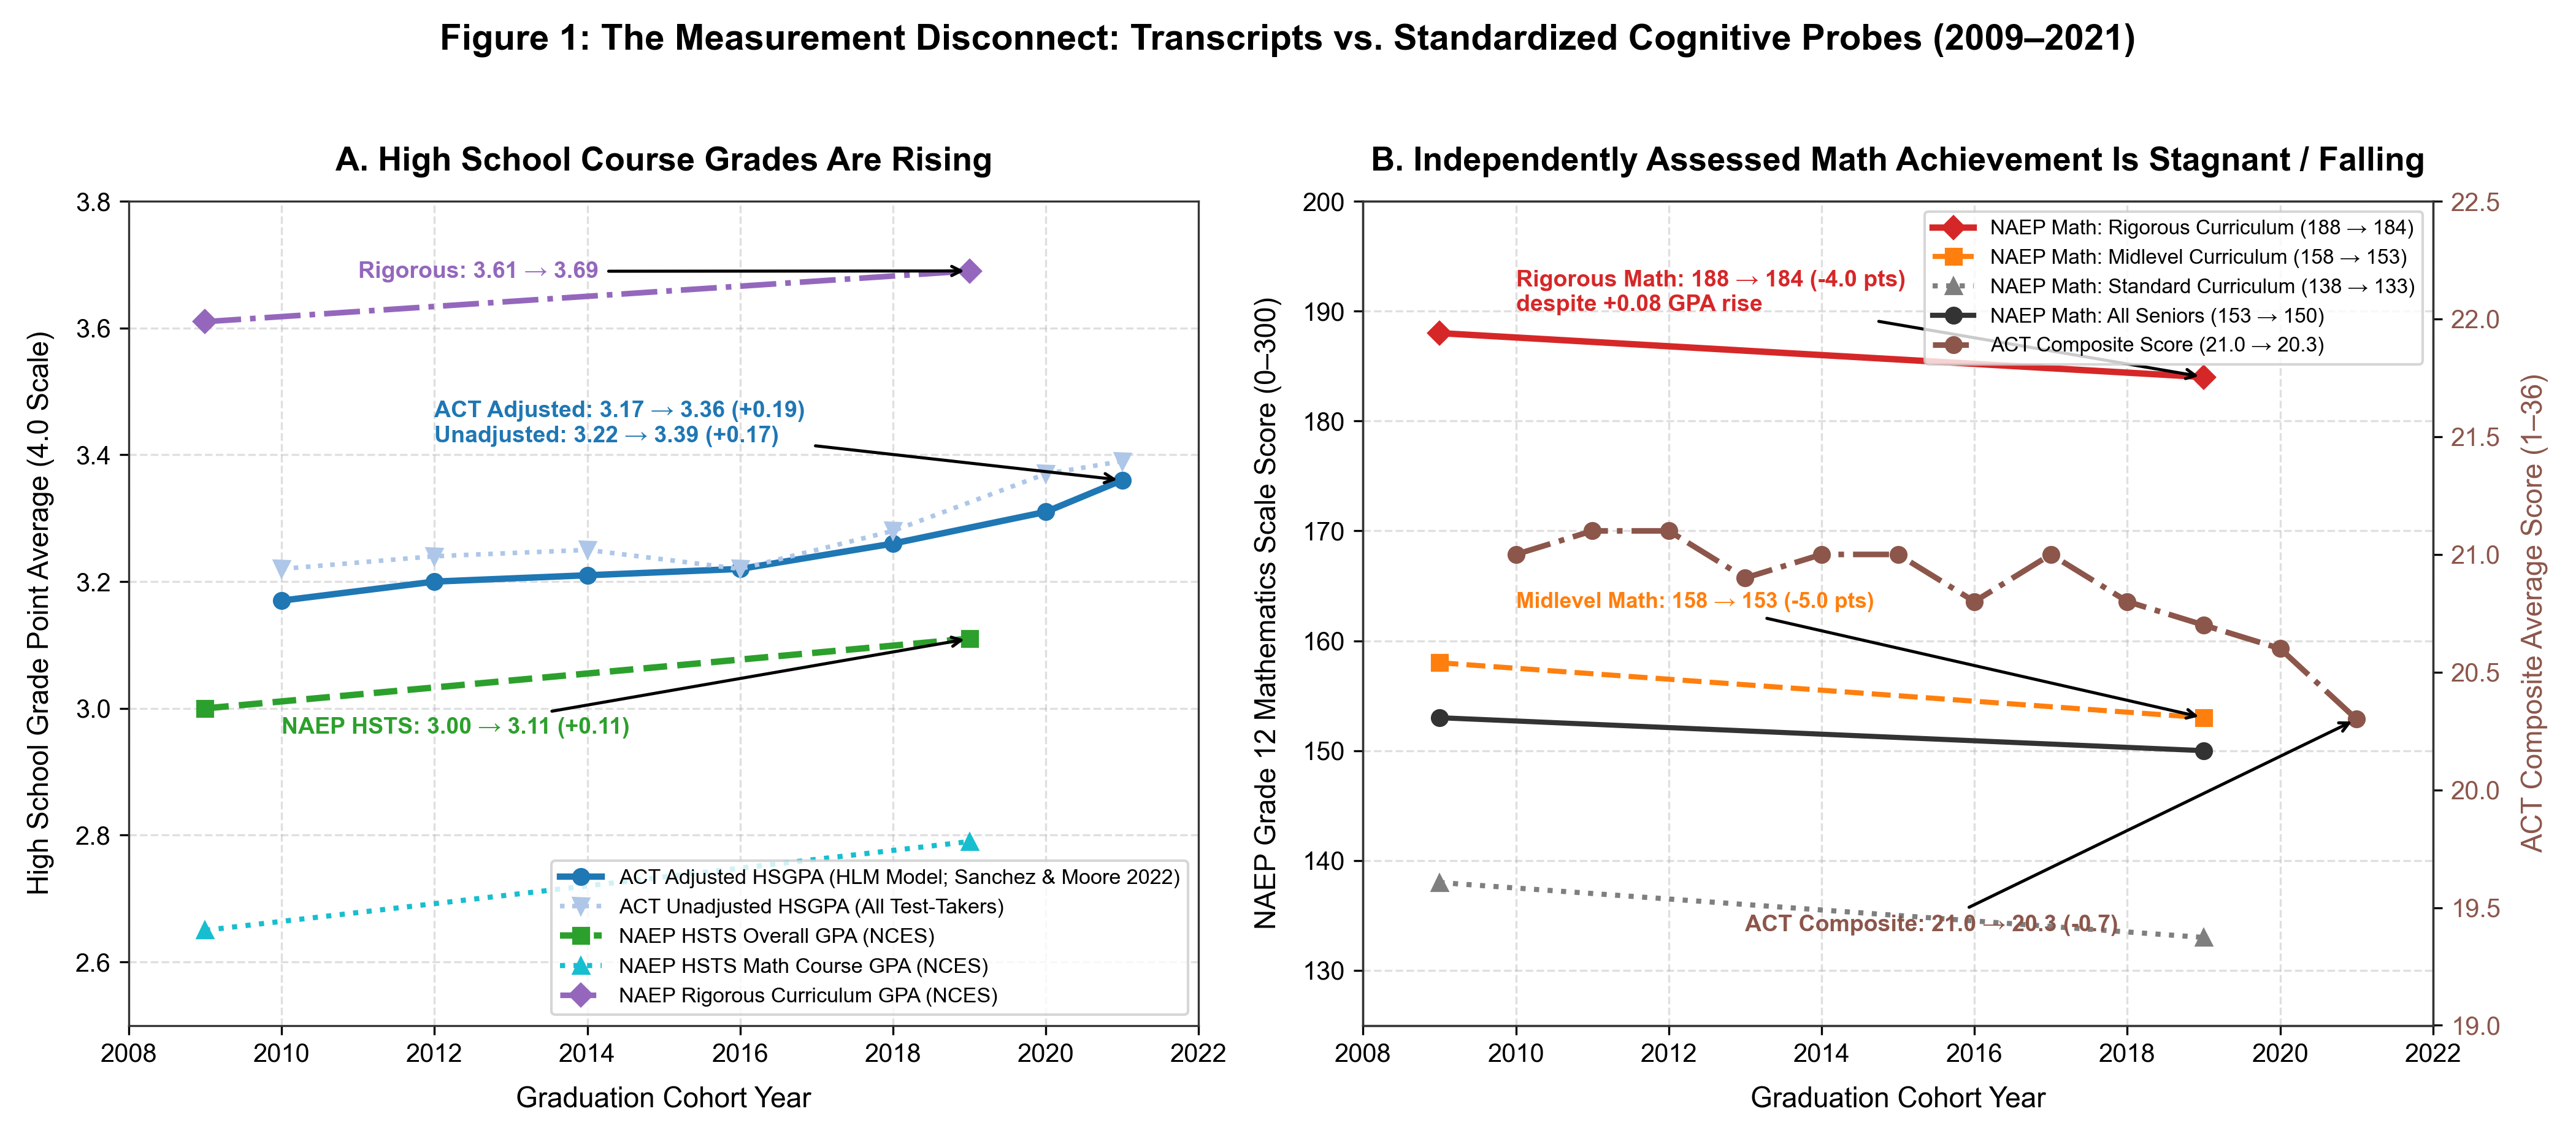

In [3]:
# Display Graph 1: The Measurement Disconnect
from IPython.display import Image
Image(filename=str(FIG_DIR / "01_national_gpa_vs_achievement.png"), width=900)


## 3. The Chicago Tension: Why Grades Still Contain Meaningful Information

It would be tempting to look at Graph 1 and conclude that standardized test scores measure true learning, while high school grades are completely fraudulent and inflated.

**That conclusion is incorrect.**

In a landmark 2020 study from the University of Chicago Consortium on School Research (CCSR), Elaine Allensworth and Kallie Clark examined Chicago Public Schools graduates, analyzing **17,753 graduates who immediately enrolled in four-year colleges** (drawn from a broader cohort of 55,084 high school graduates) to ask which measure better predicted **six-year college degree completion**: high school GPA or ACT scores.

The findings overturned conventional assumptions:
- **High school GPA was overwhelmingly more predictive of six-year college graduation than ACT scores across all high schools.**
- Published degree completion rates ranged from approximately **20% for students with high school GPAs below 1.5** to approximately **80% for students with GPAs of 3.75 or higher**.
- Once high school GPA was controlled for, ACT scores accounted for **less than 1% of the variation** in college graduation rates across high schools.
- A student with a 3.5 GPA and an ACT score of 18 graduated from college at a far higher rate than a student with a 2.5 GPA and an ACT score of 26.

### Why Do Grades Predict Success Even When They Are Inflated?
Standardized tests measure on-demand cognitive speed and item familiarity over a single 3-hour sitting. In contrast, course grades capture **multi-month non-cognitive and behavioral stamina**:
- Consistently showing up to class every day across 180 school days.
- Managing deadlines, homework submission, and long-term projects.
- Emotional regulation, compliance with adult expectations, and self-advocacy.
- Seeking help, retaking quizzes, and navigating institutional bureaucracies.

These behavioral habits are precisely the capabilities required to survive college and hold employment. 

**The Tension**: Grades can become inflated while still containing profound, meaningful predictive information. Standardized tests can be narrow measures of academic skills while providing vital independent evidence against grade inflation. The question is not which metric is "good" or "bad"; it is **what each represents, and how attaching accountability stakes changes its meaning.**


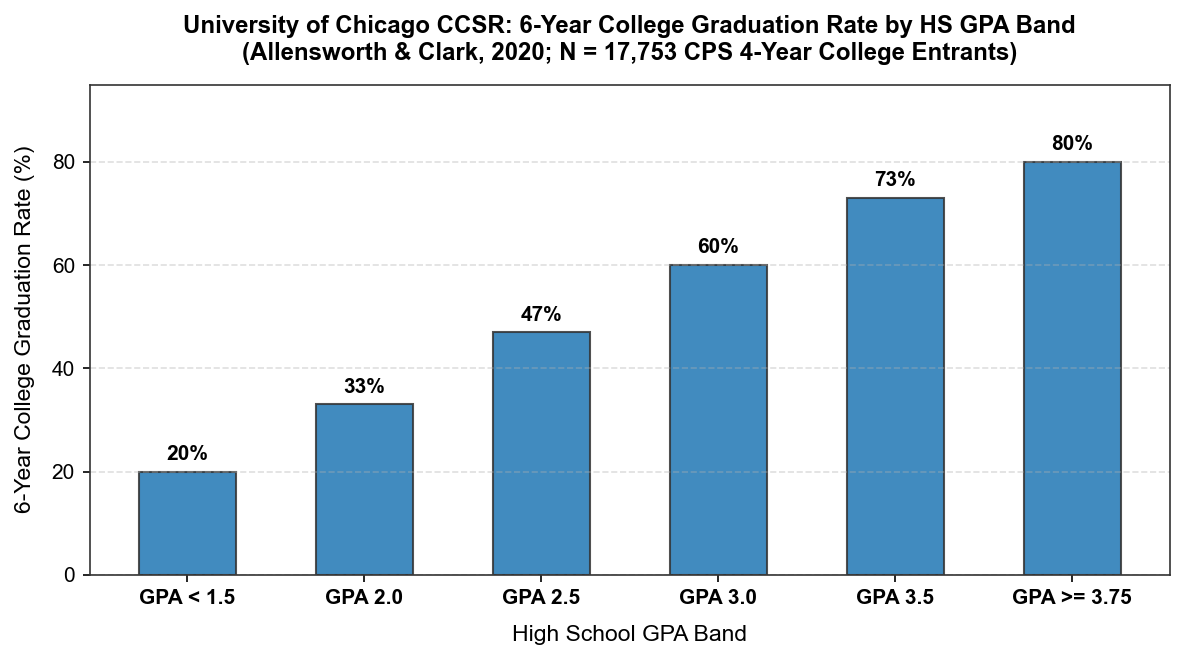

In [4]:
# Load and inspect University of Chicago CCSR empirical parameters
df_ccsr = pd.read_csv(PROCESSED_DIR / "uchicago_college_prediction.csv")

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
x = np.arange(len(df_ccsr))
width = 0.55

bars = ax.bar(x, df_ccsr["college_grad_rate_pct"], width, color="#1f77b4", edgecolor="#333333", alpha=0.85)

ax.set_ylabel("6-Year College Graduation Rate (%)", fontsize=11, labelpad=8)
ax.set_xlabel("High School GPA Band", fontsize=11, labelpad=8)
ax.set_title("University of Chicago CCSR: 6-Year College Graduation Rate by HS GPA Band\n(Allensworth & Clark, 2020; N = 17,753 CPS 4-Year College Entrants)", fontsize=11.5, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(df_ccsr["gpa_bracket"], fontsize=10, fontweight="semibold")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(0, 95)

# Add value labels
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 1.5, f"{h:.0f}%", ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


## 4. Missouri as a Timely Case Study: The September 2026 A–F Framework

On **September 15, 2026**, the Missouri State Board of Education formally voted to approve a new **A–F school and district grading framework**, implementing Executive Order 26-01.

The framework aggregates multiple indicators into a single letter grade:
- Academic Achievement Status (MAP Performance Index in ELA, Math, Science)
- Value-Added Growth (Growth residuals derived with the University of Missouri)
- Growth Toward Proficiency (Transitions from Basic to Proficient)
- Graduation Cohort Rates (4-, 5-, 6-, and 7-year cohort graduation rates)
- Postsecondary Readiness (Advanced coursework, dual credit, industry credentials, and ACT/work readiness benchmarks)

DESE plans to pilot the system using 2024–25 data before releasing public letter grades.

### The Institutional Accountability Cascade
The state framework establishes a multi-tiered pressure cascade:
```mermaid
flowchart TD
    State["1. State Board of Education & DESE<br>Approves A–F framework; publishes letter grades; threatens accreditation."]
    District["2. District Administration & School Boards<br>Face public ranking; superintendent evaluations tied to APR score."]
    Principal["3. High School Principals<br>Pressure to maintain >= 90% graduation rate and reduce course failures."]
    Teacher["4. Classroom Mathematics Teachers<br>Assign course grades; balance instructional standards against pass-rate targets."]
    Student["5. Students & Families<br>Receive transcript marks; credentialed without guaranteed algebraic mastery."]

    State --> District
    District --> Principal
    Principal --> Teacher
    Teacher --> Student
```

### The Institutional Power Struggle
At the September 15, 2026 State Board meeting, superintendents and school leaders from Kansas City, St. Louis, and rural Missouri pushed back sharply against the framework:
- **Poverty Conflation**: School leaders warned that academic status measures correlate strongly with student poverty, meaning letter grades risk branding high-poverty communities as "failing" regardless of school effort.
- **Accreditation Confusion**: Leaders argued that parents and realtors will conflate accountability letter grades with formal legal accreditation.
- **The Target Trap**: School leaders warned that assigning high-stakes letter grades incentivizes districts to push graduation rates and course pass rates higher through credit recovery, rather than addressing instructional deficits.

This local policy debate gives us a concrete, real-world lens to investigate how accountability systems reshape secondary mathematics.


## 5. Why Focus on Algebra I?

Secondary Algebra I is uniquely suited for empirical research because:
1. **The Gateway Course**: Passing Algebra I is the foundational prerequisite for geometry, Algebra II, college entrance, and high school graduation across Missouri.
2. **Dual Parallel Observation**: Students in Missouri Algebra I generate two distinct, contemporaneous marks:
   - A **teacher-assigned course letter grade** (A, B, C, D, F) reflecting classroom assignments, tests, effort, and homework over 36 weeks.
   - An **external statewide End-of-Course (EOC) assessment** administered at the end of the year, scored on a standardized scale (100–500 MPI) by DESE.
3. **The State Participation Mandate**: Missouri requires every student to *participate* in the Algebra I EOC (or Algebra II for middle-school completers) for federal and state accountability under MSIP 6. Critically, Missouri does *not* require students to pass the EOC to graduate. High school graduation requires course credit, not state test proficiency.
4. **The Researchable Question**:
   - What does passing Algebra I actually certify about a student's mathematical understanding?
   - What institutional pressures cause a passing course grade and demonstrated test proficiency to diverge?


## 6. Part 4: Kansas City High Schools — Credential Compression vs. Learning Dispersion

We now turn to the empirical data from Missouri public high schools. We link:
- Official DESE building-level 4-year graduation rates from the MSIP 6 supporting records.
- Mathematics MAP Performance Index (MPI) scores (representing high school Algebra I EOC performance).
- Building-level student poverty (Free and Reduced Price Lunch % and USDA Direct Certification %).
- College and Career Readiness (CCR) graduate percentages.
- High school enrollment and attendance rates.

Let's load the Kansas City high school panel and examine Table 2.


In [5]:
# Load Kansas City High School Benchmark Table
df_kc_table = pd.read_csv(TABLES_DIR / "table2_kc_high_schools_2022_2025.csv")
print(f"[*] Total KC Metro High Schools: {len(df_kc_table)}")

# Show top 5 and bottom 5 by Math MPI
display(pd.concat([df_kc_table.head(5), df_kc_table.tail(5)]).style.set_properties(**{'text-align': 'left'}))


[*] Total KC Metro High Schools: 45


,District,High School,Typology,Graduation Rate 2022 (%),High School Math MPI,CCR Graduate (%),FRPL Poverty (%),Direct Certification (%),Attendance 90/90 (%),Enrollment
0,KEARNEY R-I,KEARNEY HIGH,Outer Suburban,96.700000,457.800000,65.800000,8.671859,3.033981,77.900000,834.000000
1,PARK HILL,PARK HILL HIGH,Outer Suburban,94.200000,428.400000,73.200000,16.024660,6.677437,70.600000,1875.000000
2,PARK HILL,PARK HILL SOUTH HIGH,Outer Suburban,87.600000,426.200000,74.200000,14.595661,8.924731,74.900000,1842.000000
3,LEE'S SUMMIT R-VII,LEE'S SUMMIT WEST HIGH,Outer Suburban,97.900000,409.800000,69.000000,4.778533,3.112450,86.100000,2044.000000
4,LEE'S SUMMIT R-VII,LEE'S SUMMIT SR. HIGH,Outer Suburban,93.900000,407.700000,53.000000,13.223385,7.239583,79.300000,1919.000000
40,KANSAS CITY 33,EAST HIGH SCHOOL,Urban Core (KCPS),65.100000,294.100000,28.300000,100.000000,39.118705,30.800000,1065.000000
41,KANSAS CITY 33,CENTRAL HIGH SCHOOL,Urban Core (KCPS),55.800000,289.800000,29.900000,100.000000,49.532710,23.200000,467.000000
42,KANSAS CITY 33,PASEO ACAD. OF PERFORMING ARTS,Urban Core (KCPS),82.500000,289.800000,32.100000,100.000000,33.898305,42.900000,654.000000
43,DELASALLE CHARTER SCHOOL,DeLaSalle Charter High School,Public Charter (KC),60.000000,288.900000,6.500000,100.000000,50.802139,34.400000,189.000000
44,HOGAN PREPARATORY ACADEMY,HOGAN PREPARATORY ACADEMY,Public Charter (KC),74.400000,277.800000,8.200000,83.943662,48.444444,35.100000,402.000000


### Graph 2: The Relationship Between Graduation and Measured Achievement in Kansas City

Graph 2 plots the official 4-Year Adjusted Cohort Graduation Rate against the Mathematics MAP Performance Index (MPI) for Kansas City high schools.
- Bubble size represents total high school enrollment.
- Colors reflect geographic typology: **Outer Suburban** (blue), **Inner-Ring Suburban** (orange), **Urban Core KCPS** (red), and **Public Charter** (purple).

Let's inspect Graph 2 below:


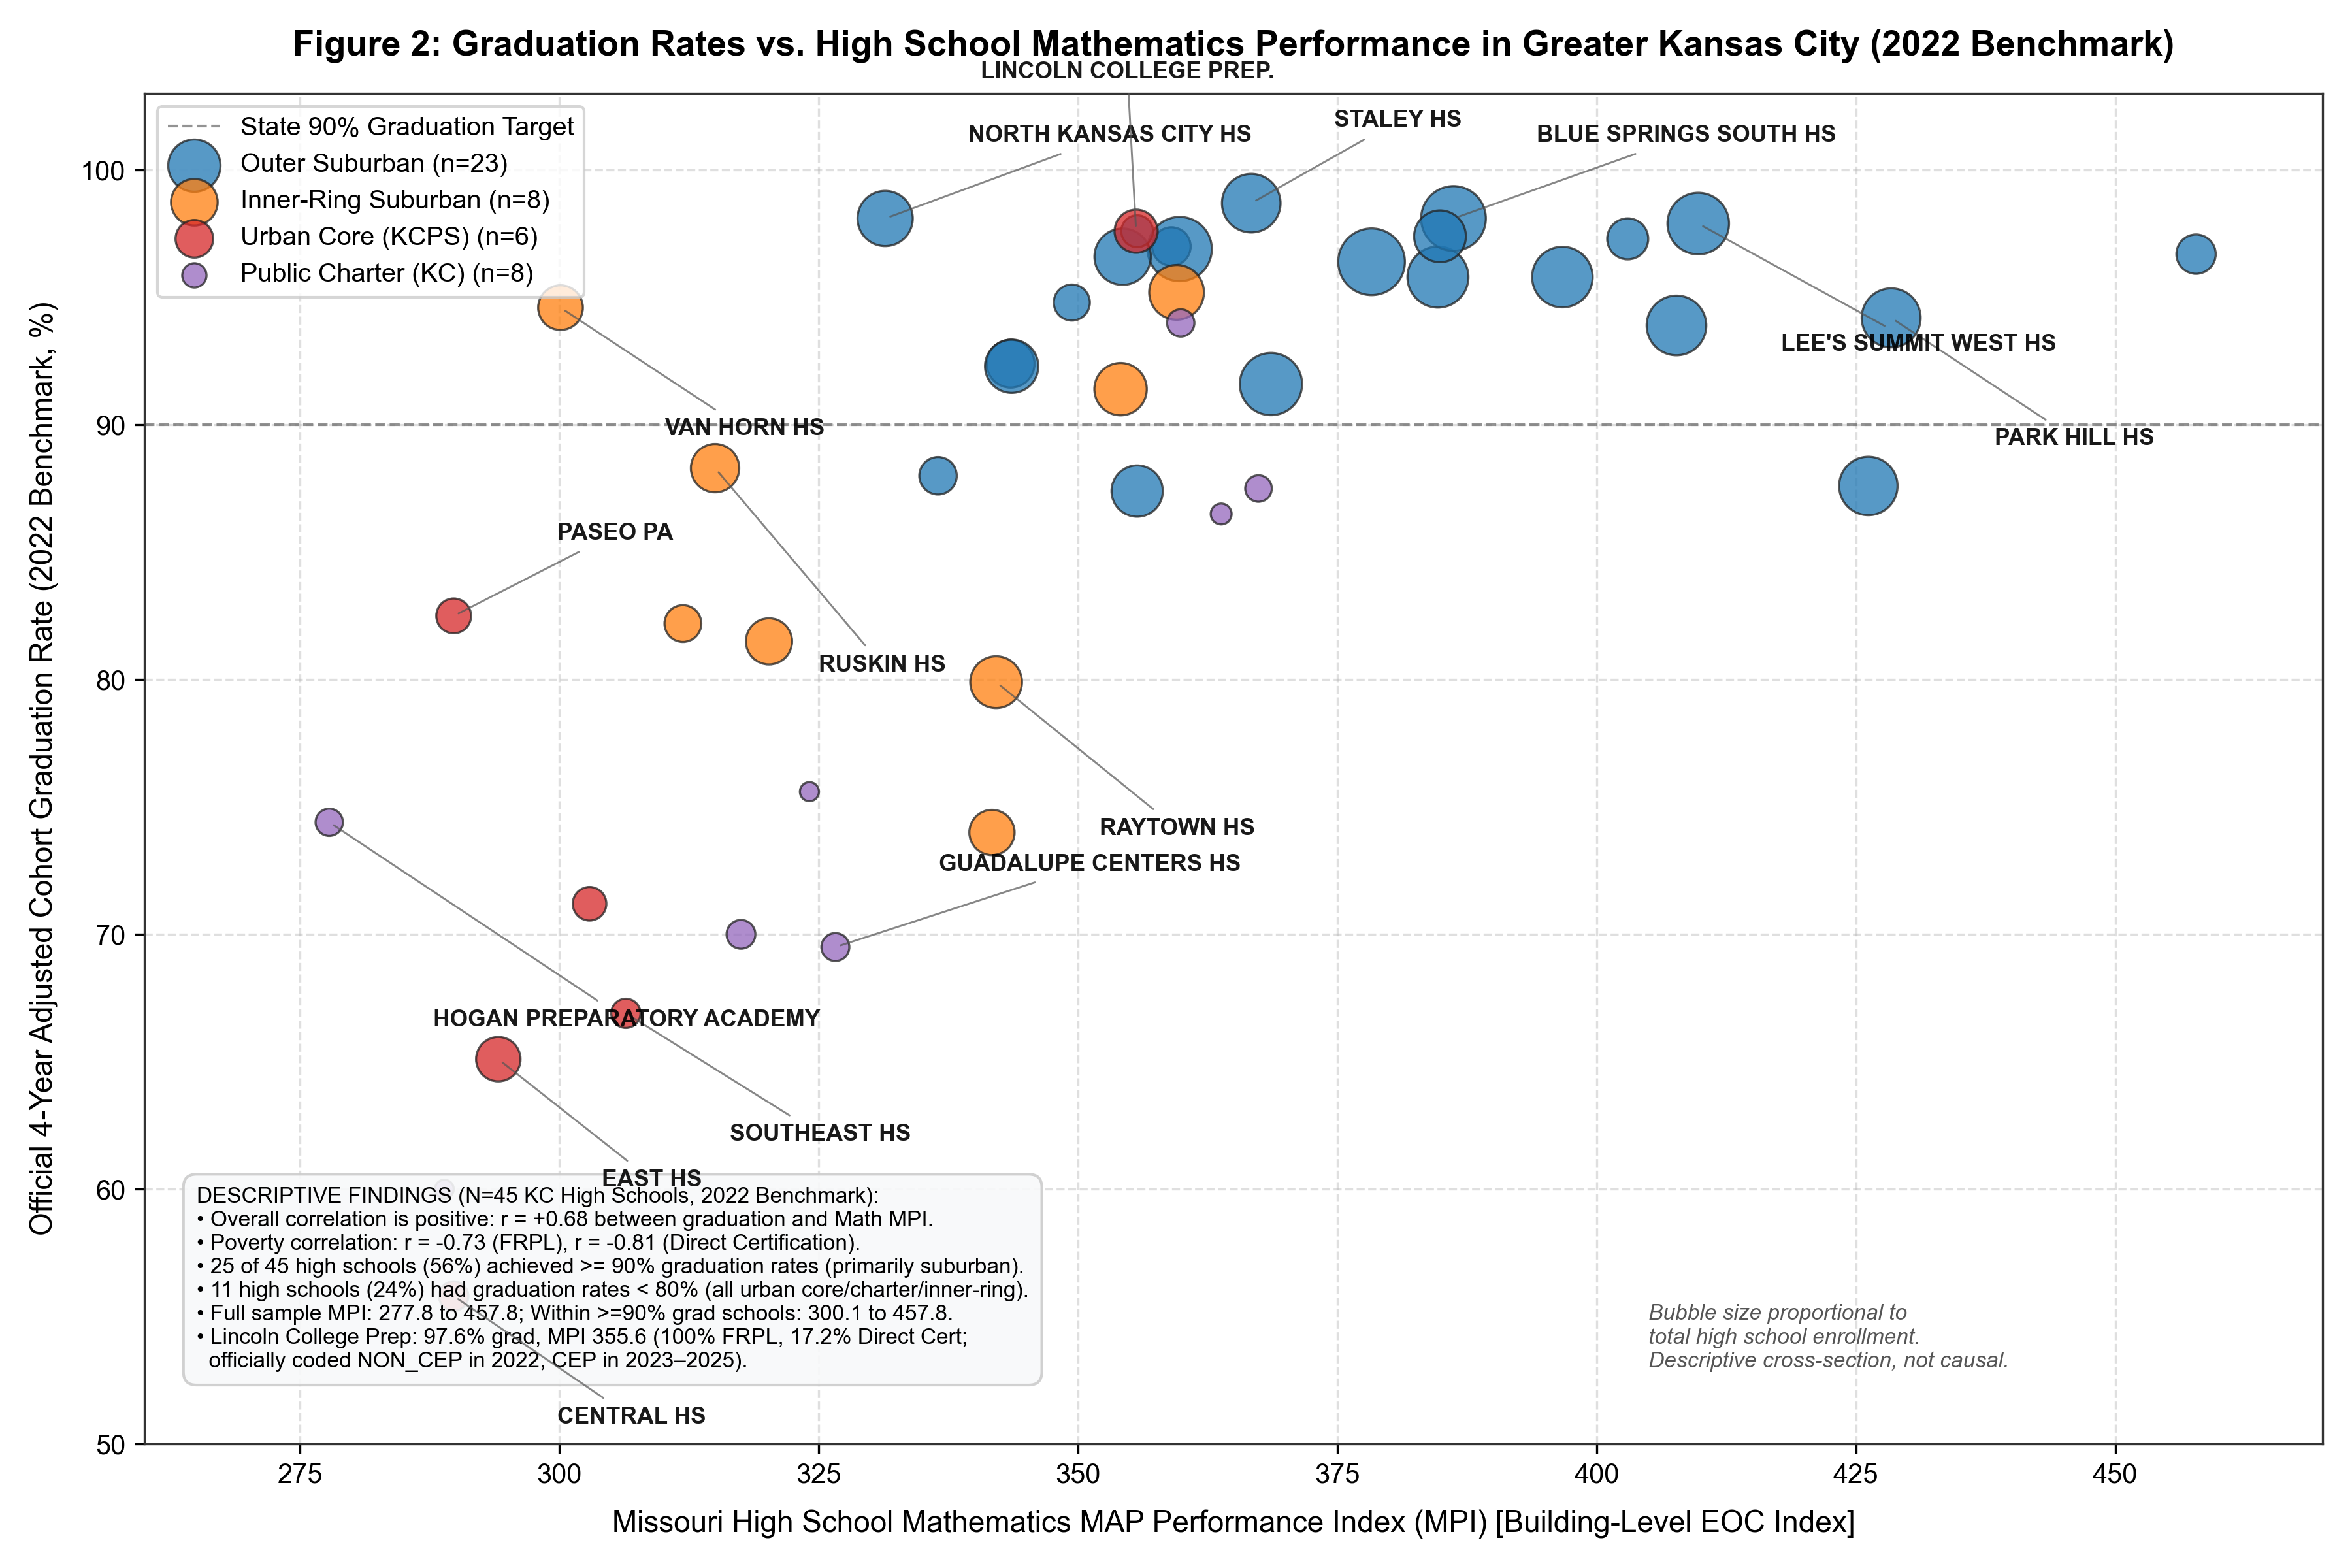

In [6]:
# Display Graph 2: KC High Schools Graduation vs. Math MPI
Image(filename=str(FIG_DIR / "02_kc_graduation_vs_math_mpi.png"), width=900)


### Key Insights from Graph 2: The Kansas City High School Landscape

The 2022 cross-sectional baseline (45 complete high schools, drawn from our 51-school, 188-record panel across 2022–2025) reveals a nuanced relationship:
1. **Positive Overall Metro Correlation ($r = +0.68$)**: Graduation rates and Mathematics MPI are positively correlated across the metro ($r = +0.6817$), driven primarily by the stark performance divide between affluent outer-suburban districts and high-poverty urban core schools.
2. **Poverty as the Dominant Predictor**:
   - Graduation Rate vs. FRPL: $r = -0.7343$; vs. Direct Certification: $r = -0.8076$
   - Math MPI vs. FRPL: $r = -0.7582$; vs. Direct Certification: $r = -0.8285$
   - *Direct Certification Correction*: Selective magnet Lincoln College Prep is reported at 100% FRPL on state dashboards, but its USDA Direct Certification rate is only 17.2%. Notably, in official DESE records, Lincoln is coded as `NON_CEP` in 2022 before transitioning to `CEP` in 2023–2025. Direct Certification resolves this administrative meal artifact.
3. **Upper-Tier Compression vs. Urban Spread**:
   - Rather than universal compression across all schools, **25 schools (56%)** have graduation rates $\ge 90\%$, while **11 schools (24%)** fall below 80% (concentrated among urban neighborhood and charter schools).
   - Within the high-graduation tier ($\ge 90\%$), measured mathematics achievement spans a wide continuum from **300.1 to 457.8** (nearly 160 index points; across the full 45-school baseline, MPI ranges from 277.8 to 457.8).
4. **Striking Paired School Comparisons**:
   - **Van Horn High School** in Independence reports an official graduation rate of **94.6%**—matching **Park Hill High School (94.2%)** and **Lee's Summit High School (93.9%)**.
   - Yet Van Horn's Math MPI is **300.1** (borderline Basic), while Park Hill's Math MPI is **428.4** and Lee's Summit is **407.7**.
   - **Ruskin High School** in Hickman Mills graduates **88.3%** of its senior cohort, yet its Math MPI is **315.0** and its College and Career Readiness rate is **29.9%**.
   - **North Kansas City High School** graduates **98.1%** of students with a Math MPI of **331.4**.

### Hypothesizing Mechanisms Behind the Asymmetry
Under both federal accountability (ESSA) and Missouri's MSIP 6 system, high schools face dual, often conflicting accountability incentives: they are evaluated both on student performance on standardized assessments (such as the Algebra I EOC) and on cohort graduation rates (where falling below 80% triggers regulatory scrutiny). 

How do schools with modest standardized mathematics performance sustain graduation rates matching the most affluent suburbs? Several plausible operational mechanisms are widely discussed in educational policy:
- **Online Credit Recovery**: Modular software pathways allowing students who failed a semester of required coursework to recover credit through self-paced digital units.
- **Grading Floors & Minimum Grading Policies**: Policies establishing a 50% floor on quarter grades to prevent early academic failure from rendering semester recovery mathematically impossible.
- **Intensive Student Retention & Tiered Support**: Targeted intervention blocks, attendance outreach, and counseling supports designed to keep vulnerable students enrolled through twelfth grade.
- **Divergent Course-Passing Standards**: Subjective classroom grading practices where teachers reward effort, attendance, and project completion, decoupling course passage from external assessment proficiency.

Crucially, observing a statistical divergence between graduation rates and mathematics test scores does not prove that unmeasured grading floors or credit recovery caused the gap. Determining which mechanisms operate in any given building requires auditing classroom-level grade books, credit-recovery transcripts, and student-level assessment records.


## 7. Part 5: Inside the Classroom — The Algebra I Signaling Benchmark

When a student receives a passing grade, whose definition of success has actually been satisfied? What does an "A", "B", "C", or "D" in Algebra I actually communicate about a student's mathematical understanding?

### The North Carolina Empirical Benchmark
Because individual student course grades linked to statewide EOC test records are not yet publicly released in Missouri, establishing that exact concordance locally remains an active, open research question. 

However, this exact empirical question was answered rigorously by economist Seth Gershenson using statewide administrative records from North Carolina in *Grade Inflation in High Schools (2005–2016)* (Fordham Institute, 2018, Figure 2, p. 16; Tyner & Gershenson, 2020). Analyzing administrative records for approximately **250,000 North Carolina Algebra I students from 2014 to 2016**, Gershenson documented the true empirical distribution of external proficiency across course grade tiers:

- **'A' Students**: **92%** achieved proficiency or advanced on the state EOC; only **8%** were non-proficient.
- **'B' Students**: **36% failed to achieve proficiency** on the state EOC (64% proficient).
- **'C' Students**: **71% failed to reach proficiency** (only 29% proficient).
- **'D/F Combined'**: **90% failed to reach proficiency** on the external examination (only 10% proficient; reported as a combined category in published research).

Crucially, North Carolina policy during this period mandated that student scores on the standardized EOC exam counted for at least 20% of their final course letter grade. Because the standardized assessment was already partially embedded within the course grade itself, the two measures were not completely independent. This makes the observed discordance—over one-third of 'B' students and seven in ten 'C' students failing proficiency—even more striking.

In a separate subsequent report, *Great Expectations: The Impact of Rigorous Grading Standards on Student Achievement* (Fordham Institute, 2020), Gershenson demonstrated that teacher grading standards vary substantially across classrooms, and that exposure to more rigorous grading standards directly benefits students—substantially improving their subsequent performance in Geometry and Algebra II. Furthermore, the companion econometric paper by Tyner & Gershenson (2020, *Economics of Education Review*, 78, 102037) confirmed that higher grading standards benefit all students, with particularly pronounced advantages for disadvantaged students.

Let's examine Graph 3 below:


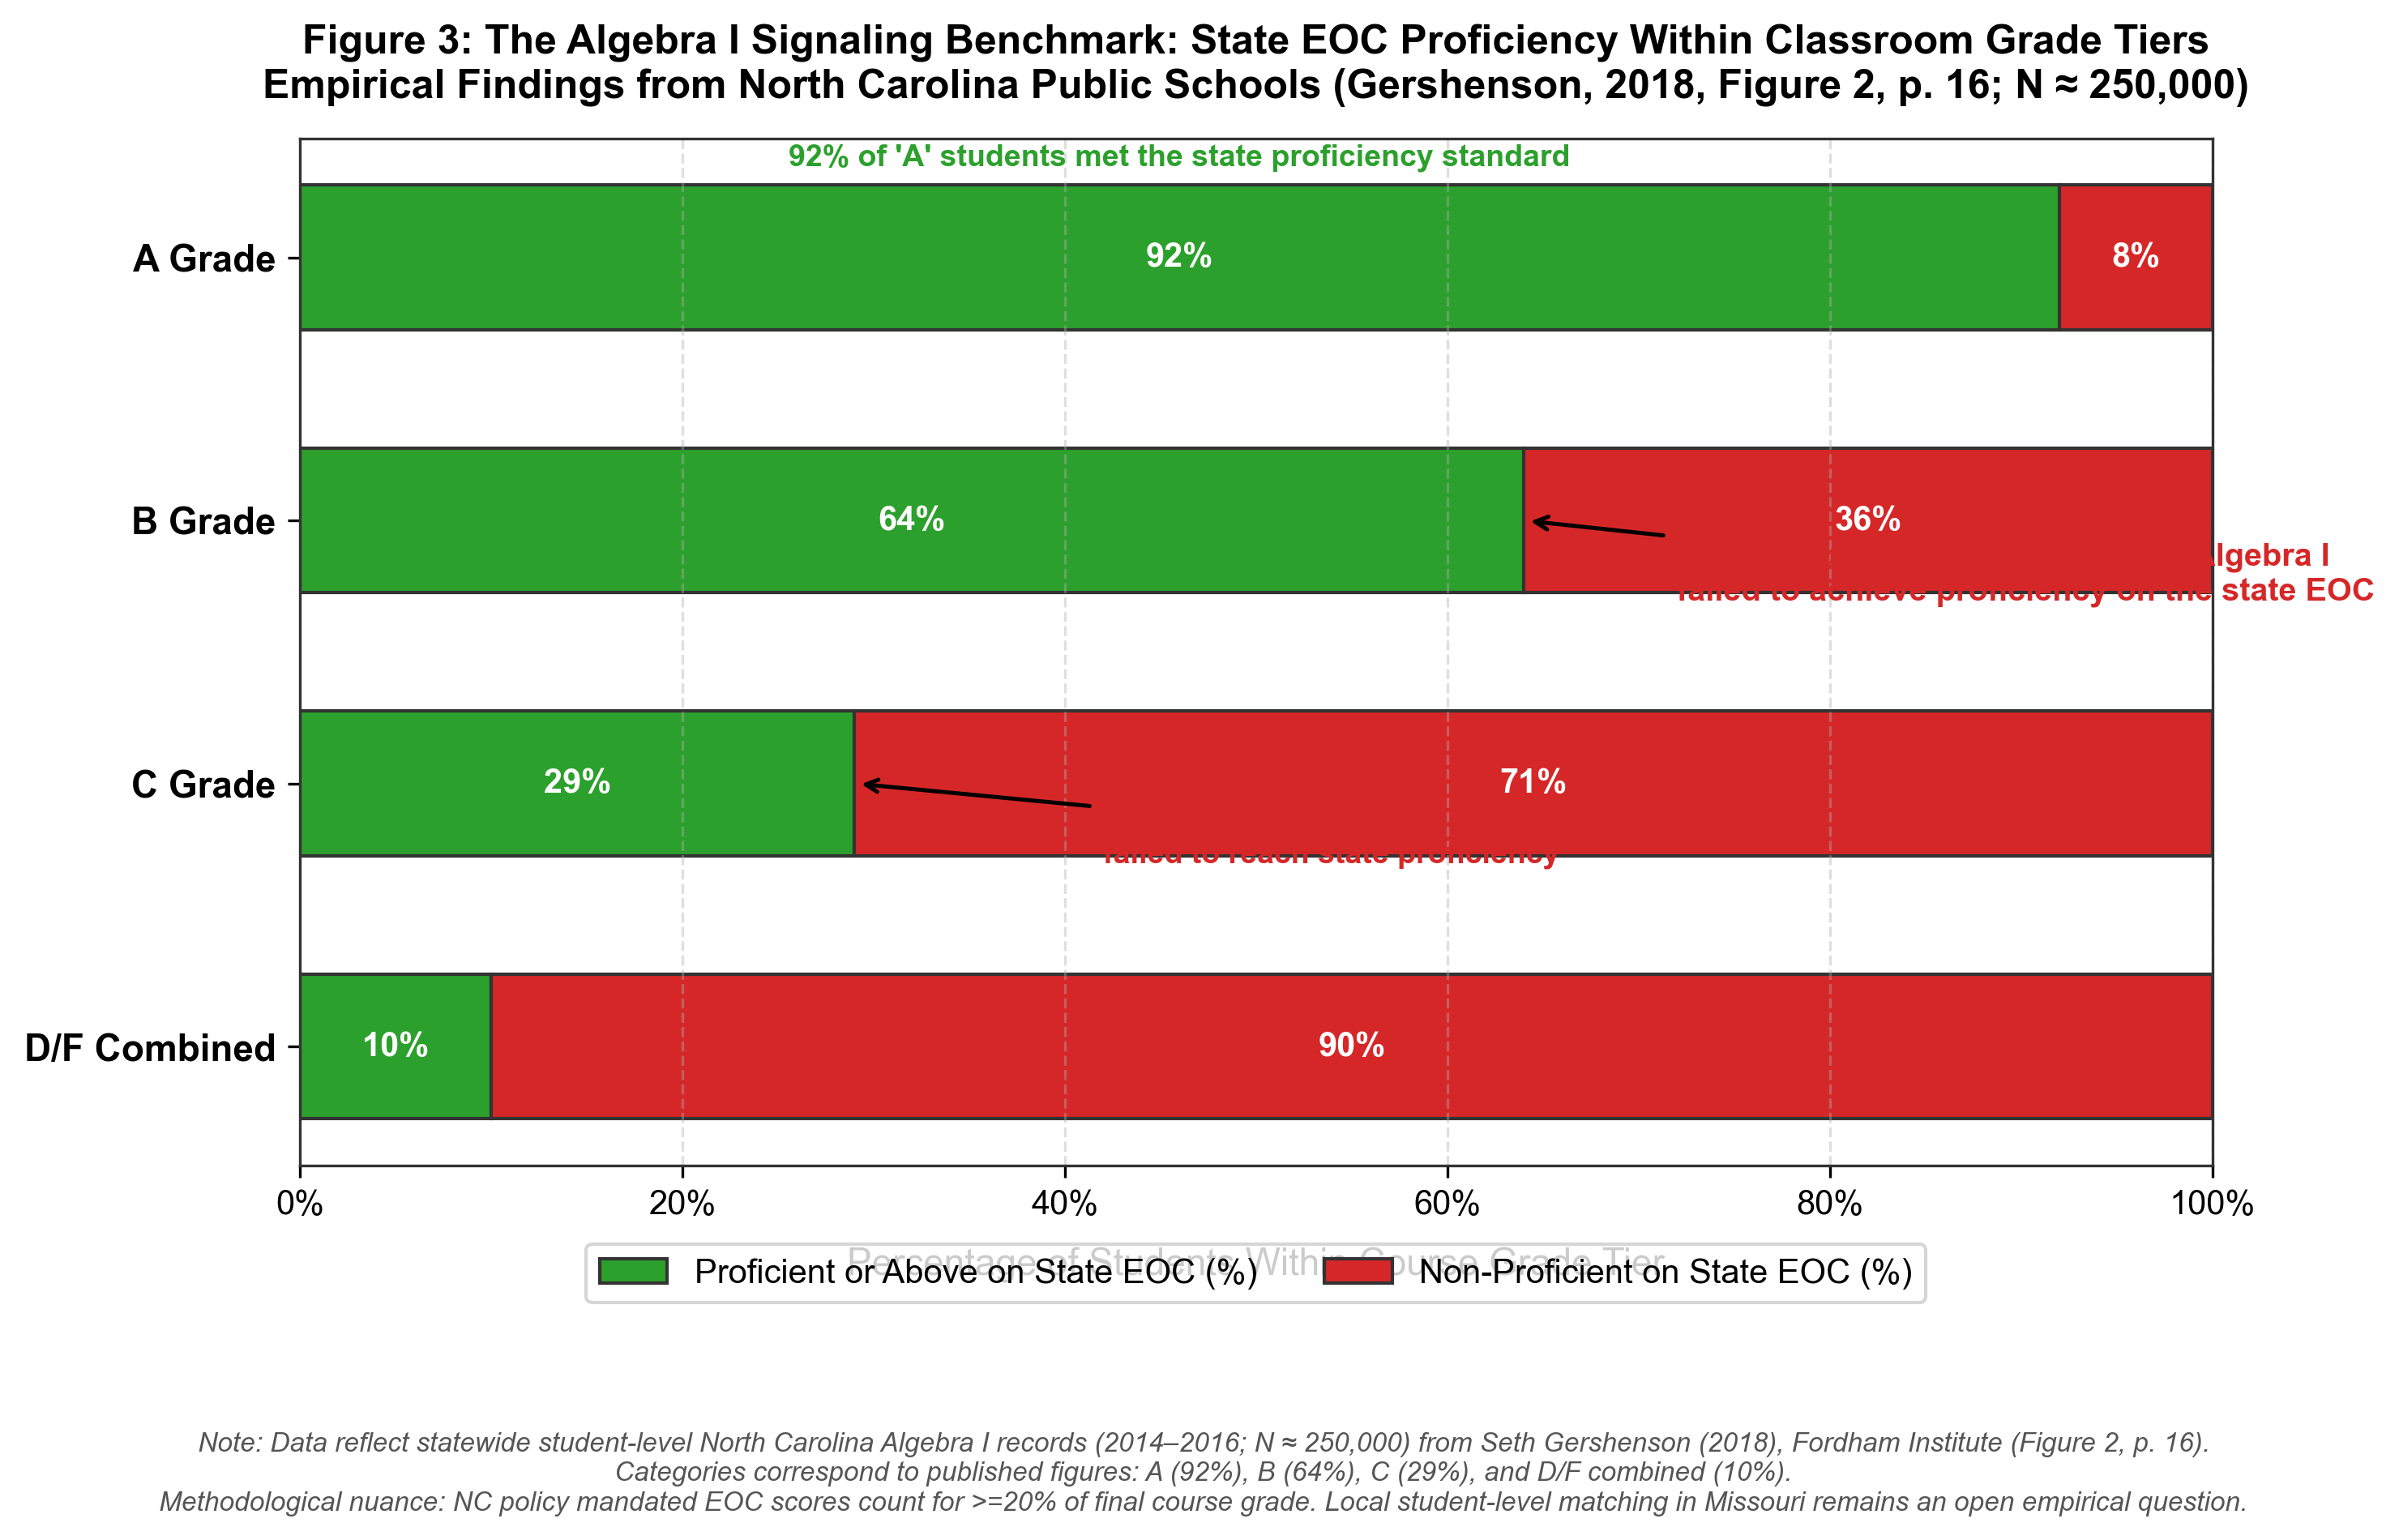

In [7]:
# Display Graph 3: The Algebra I Signaling Benchmark
Image(filename=str(FIG_DIR / "03_algebra1_grade_proficiency_gap.png"), width=900)


## 8. Part 6: Reconciling the Incentive Literature — Do Incentives Work?

A responsible empirical investigation must not begin by assuming that accountability incentives are purely corrupting. We must read the evidence on both sides.

### The Dueling Realities of Educational Incentives
1. **Incentives Distort Behavior & Inflate Credentials (Jacob, 2005; Gershenson, 2018; McElroy, 2023)**:
   - Brian Jacob's evaluation of high-stakes testing in Chicago proved that accountability produced significant score inflation through strategic gaming: assigning low-performing students to special education, teaching narrowly to the test format, and credit recovery.
   - Seth Gershenson (2018; Tyner & Gershenson, 2020) demonstrated that subjective course grades decouple from standardized assessments under failure-rate scrutiny, with 36% of 'B', 71% of 'C', and 90% of 'D/F' students in Algebra I failing external state proficiency, even with the EOC counting for >=20% of the course mark.
   - Katherine McElroy (2023) (*Does test-based accountability improve more than just test scores?*, *Economics of Education Review*, 94, 102381) demonstrated that high school accountability mandates significantly increased graduation rates, but **failed to increase college attendance or bachelor's degree attainment**, indicating credential inflation at the secondary exit boundary.
2. **Incentives Produce Real Learning & Rigor Benefits (Dee & Jacob, 2011; Gershenson, 2020)**:
   - In their national NBER study of No Child Left Behind, Thomas Dee and Brian Jacob found statistically significant, authentic gains in mathematics achievement on the **independent, low-stakes NAEP exam** (+0.23 SD in 4th grade, +0.10 SD in 8th grade).
   - In *Great Expectations* (2020), Gershenson showed that teachers with higher grading standards induce genuine gains in student learning that persist into subsequent math courses.
   - Accountability can force school systems to reallocate coaching, extended math blocks, and tutoring resources toward struggling students.

Let's inspect the structured literature synthesis matrix below:


In [8]:
# Display Table 3: Synthesis of Empirical Research on Accountability & Incentives
df_t3 = pd.read_csv(TABLES_DIR / "table3_literature_matrix.csv")
display(df_t3.style.set_properties(**{'text-align': 'left'}))


,Study,Setting / Design,Target Measure,Observed Behavioral Distortion,Authentic Learning Finding,Theoretical Mechanism,Observed Distortion
0,Campbell (1979),Methodological Treatise,Quantitative social indicators,Test corruption and curriculum narrowing when indicators become targets,Social indicators reflect reality only until attached to administrative consequences,Campbell's Law: indicator corruption,nan
1,Jacob (2005),"Chicago Public Schools (1996 reform, DiD)",ITBS high-stakes test scores,nan,Gains failed to generalize to low-stakes state tests (IGAP) or NAEP,Strategic gaming around accountability threshold,"Placement into special education (+1-2 pp), retention, narrow test prep, answer alteration"
2,Dee & Jacob (2011),National No Child Left Behind (Comparative interrupted time-series),State AYP proficiency benchmarks,nan,"Statistically significant gains on independent low-stakes NAEP Math (+0.23 SD in 4th, +0.10 SD in 8th)",Accountability can compel authentic instructional effort and resource reallocation,Differential focus on bubble students near proficiency cut score
3,Allensworth & Clark (2020),"Chicago Public Schools (17,753 four-year college enrollees for 6-yr completion; 55,084 cohort for enrollment)",High School GPA vs. ACT Scores,nan,HS GPA is 5x more predictive of college graduation than ACT; captures multi-month persistence and attendance,Grades reflect multi-attribute behavioral habits decisive for college survival,Grading standards vary across high schools; test scores do not consistently correlate with college success
4,Gershenson (2018) / Tyner & Gershenson (2020),"North Carolina Public Schools (Algebra I panel, 2014–2016 for Fig 2 [N ≈ 250,000]; 2006–2016 master panel)",Course letter grades vs. Algebra I EOC scores (EOC weighted >= 20% of final grade),nan,External assessments provide an anchor against grade compression; EOC scores predict subsequent ACT math better than grades,Subjective grades without external anchor mask skill deficits,"36% of 'B', 71% of 'C', and 90% of 'D/F' students failed state EOC proficiency; subjective grading standards decouple under grade inflation"
5,Gershenson (2020),"North Carolina Public Schools (Great Expectations, Fordham Institute, 2006–2016 panel)",Grading standards / teacher grading leniency,nan,"Higher grading standards directly improve student learning and subsequent performance in Geometry and Algebra II, especially for disadvantaged students",Rigorous expectations motivate effort and substantive mastery,Teacher grading standards vary substantially across classrooms and schools
6,Sanchez & Moore (2022),National ACT Research Panel (2010–2021; N > 2M),High School GPA,nan,"Grade inflation occurred across all school types, accelerating during COVID-19 grading policies","Systemic leniency, transcript signaling competition",Adjusted GPA rose 3.17 → 3.36 while ACT Composite dropped 21.0 → 20.3; unadjusted GPA rose 3.22 → 3.39
7,McElroy (2023),"US High School Accountability Mandates (Economics of Education Review, 94, 102381)","High school graduation, college attendance, and BA receipt (educational attainment; does not evaluate earnings)",nan,Test-based accountability mandates significantly elevated high school completion rates,Credential expansion without demonstrated postsecondary human capital gains,Graduation rates rose significantly under test-based accountability mandates; no statistically significant overall effect on college attendance or bachelor's degree attainment


## 9. Conclusion: Returning to the Student

Let us end where we began: with the student.

A student in an urban high school receives a **'B' in Algebra I**. 
- To the **student**, the grade communicates success: they showed up, completed worksheets, behaved cooperatively, and earned a passing mark on their transcript.
- To the **parent**, the grade confirms that their child is on track for college and a middle-class career.
- To the **school administrator**, the grade represents an averted failure, a protected graduation rate, and an improved APR report for state accountability.
- But to the **college admissions office** and the **community college placement exam**, that 'B' may mask a score in the Below Basic tier of algebraic proficiency, requiring the student to spend tuition dollars on non-credit remedial mathematics.

### The Central Empirical Lesson & Potential Mechanisms
The central empirical lesson of this descriptive study is that educational measures and demonstrated competencies can diverge substantially without implying teacher negligence or simple bad faith.

Our data establish descriptive baselines:
- National transcripts show rising GPAs while standardized test performance stagnates.
- Chicago longitudinal records prove course grades capture multi-month persistence that tests miss, explaining why grades remain highly predictive.
- Kansas City high schools display a sharp divide between high-graduation suburban clusters and lower-graduation urban systems, alongside a wide spread of mathematics achievement among schools with $\ge 90\%$ graduation rates.
- North Carolina administrative records demonstrate that passing marks frequently decouple from standardized proficiency—even when the test is weighted in the course grade.

However, observing this statistical divergence does not prove what caused individual teachers to assign specific grades or why particular schools achieve high graduation rates. 

### The Research Agenda Ahead: Kansas City Institutional Incentive Study
To move beyond descriptive correlations and investigate the actual institutional mechanisms driving these outcomes, the immediate next research phase focuses on a **Kansas City Institutional Incentive Study**:
1. **District Grading Policies**: Audit student handbooks and district policy manuals across Kansas City area districts (KCPS, Independence, North Kansas City, Lee's Summit, Hickman Mills) to document the presence of minimum grading floors (e.g., 50% minimum F), homework-weighting caps, and retake requirements.
2. **Credit-Recovery Program Architecture**: Investigate the scale and design of digital modular credit-recovery software (e.g., Edgenuity, Apex Learning) used to clear course deficiencies.
3. **Administrative Expectations**: Analyze whether principals and instructional leaders face formal or informal failure-rate quotas or pass-rate targets tied to school accountability status.
4. **Long-Term De-Identified Student Matching**: Pursue district research partnerships to match student-level course grade books to Missouri Algebra I EOC scores and subsequent postsecondary college remediation in Missouri public institutions (DHEWD).


Saved Table 4: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-08-what-does-an-a-mean\artifacts\tables\table4_kc_institutional_decoupling_summary.csv (45 schools)
Saved Table 5: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-08-what-does-an-a-mean\artifacts\tables\table5_district_policy_matrix.csv (28 districts)


Saved Figure 4: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-08-what-does-an-a-mean\artifacts\figures\04_kc_signaling_decoupling_gap.png
Top 10 High Schools by Graduation–Achievement Rank Difference:


,District Name,School Name,4-Yr Grad Rate (%),Math Status MPI,Grad-Math Rank Diff (Pctile Pts),Policy Status in 2022,Subsequent Policy Adoption,Longitudinal Policy Exposure Role
0,NORTH KANSAS CITY 74,NORTH KANSAS CITY HIGH,98.1,331.4,63.333333,NOT_IN_EFFECT,STANDARDS_BASED_SBL (Pilot),Case_B_Pilot_Exposed_2025_26
1,INDEPENDENCE 30,VAN HORN HIGH,94.6,300.1,48.888889,VERIFIED_IN_EFFECT,TRADITIONAL_PCT,Verified_Traditional_Comparison
2,KANSAS CITY 33,LINCOLN COLLEGE PREP.,97.6,355.6,36.666667,NOT_IN_EFFECT,FLOOR_40_MINIMUM (Honors/AP/IB Exemption),Case_A_Honors_Exemption_2024_25
3,OAK GROVE R-VI,OAK GROVE HIGH,97.6,355.7,33.333333,UNVERIFIED,Unverified,Exploratory_Pending_Audit
4,NORTH KANSAS CITY 74,STALEY HIGH,98.7,366.7,28.888889,NOT_IN_EFFECT,TRADITIONAL_PCT (Non-Pilot; SBL in 26-27),Case_B_Within_District_Comparison_2025_26
5,NORTH KANSAS CITY 74,OAK PARK HIGH,96.6,354.3,24.444444,NOT_IN_EFFECT,TRADITIONAL_PCT (Non-Pilot; SBL in 26-27),Case_B_Within_District_Comparison_2025_26
6,KANSAS CITY 33,PASEO ACAD. OF PERFORMING ARTS,82.5,289.8,23.333333,NOT_IN_EFFECT,FLOOR_40_MINIMUM (Revised: 0% Missing / >=40% ...,Case_A_Active_Policy_Revised_2024_25
7,HICKMAN MILLS C-1,RUSKIN HIGH SCHOOL,88.3,315.0,22.222222,UNVERIFIED_PENDING_PRIMARY_SOURCE,FLOOR_50_DOCUMENTATION_PENDING,Exploratory_Pending_Audit
8,EXCELSIOR SPRINGS 40,EXCELSIOR SPRINGS HIGH,97.0,359.0,22.222222,UNVERIFIED,Unverified,Exploratory_Pending_Audit
9,HOGAN PREPARATORY ACADEMY,HOGAN PREPARATORY ACADEMY,74.4,277.8,17.777778,UNVERIFIED,Unverified,Exploratory_Pending_Audit


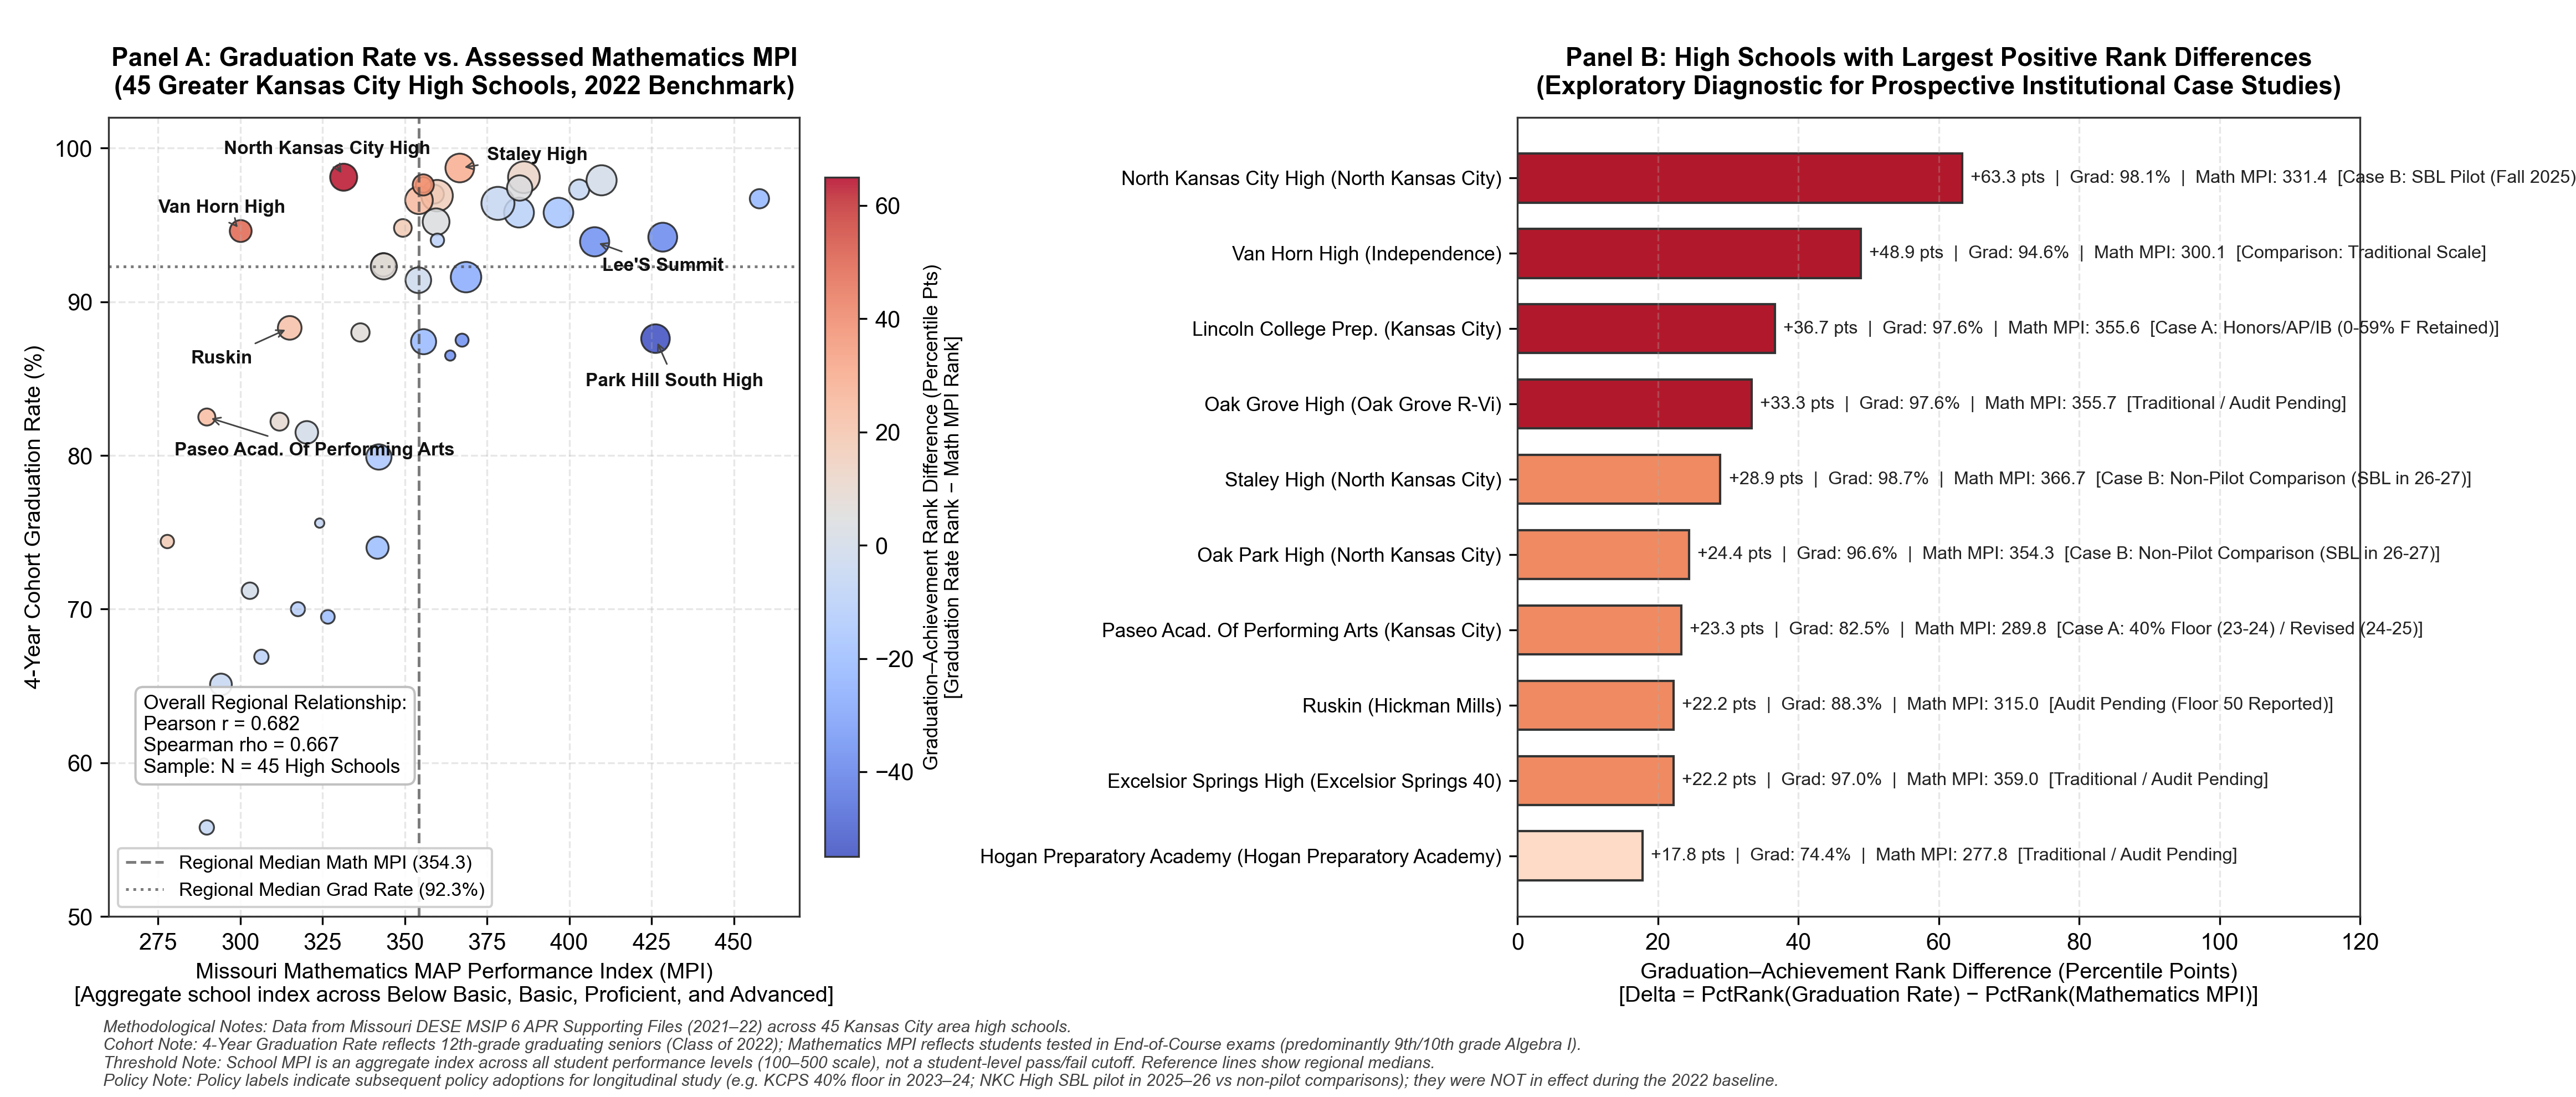

In [9]:
# Phase 2: Kansas City Institutional Incentive Analysis & Exploratory Rank Differences
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from src.analyze_institutional_incentives import load_and_process_decoupling_data, generate_tables, plot_figure_4

# Execute institutional analysis pipeline
df_merged, df_policy, df_evidence = load_and_process_decoupling_data()
generate_tables(df_merged, df_policy, df_evidence)
plot_figure_4(df_merged)

# Load and display top rank-difference high schools
t4 = pd.read_csv(TABLES_DIR / "table4_kc_institutional_decoupling_summary.csv")
print("Top 10 High Schools by Graduation–Achievement Rank Difference:")
display(t4.head(10)[["District Name", "School Name", "4-Yr Grad Rate (%)", "Math Status MPI", "Grad-Math Rank Diff (Pctile Pts)", "Policy Status in 2022", "Subsequent Policy Adoption", "Longitudinal Policy Exposure Role"]])

# Display Figure 4
display(Image(str(FIG_DIR / "04_kc_signaling_decoupling_gap.png")))


## Section 9: Institutional Policy Synthesis & Longitudinal Research Agenda (Phase 2)

The empirical results from **Figure 4** and **Table 4** clarify the relationship between school accountability measures and district policy timelines:

1. **Overall Correlation and School-Level Divergence**:
   - Across the 45 high schools in Greater Kansas City, the overall relationship between four-year cohort graduation rates and mathematics MAP Performance Index (MPI) scores is positive and fairly strong: **Pearson $r = 0.682$, Spearman rank $\rho = 0.667$**.
   - However, individual high schools show substantial differences in their relative standing. The **Graduation–Achievement Rank Difference** ($\Delta_i = \operatorname{PctRank}(G_i) - \operatorname{PctRank}(M_i)$) spans from **$-55.6$ to $+63.3$ percentile points** ($\text{SD} = 23.8$).
   - This metric serves as an **exploratory screening diagnostic** for identifying schools with divergent institutional outcomes; it is not a direct causal estimate of credential inflation.

2. **The Timing Paradox**:
   - Our audit of primary board minutes reveals that prominent grading reforms occurred **subsequent to the 2022 benchmark**:
     - **KCPS (048-078)**: The 40% minimum assignment floor was implemented in **2023–24** (and revised in 2024–25).
     - **North Kansas City (024-093)**: Standards-Based Learning (SBL) was scheduled for a pilot in **fall 2025** (including North Kansas City High) with full rollout in **2026–27**.
   - Consequently, these policies did not exist in 2022 and cannot causally explain 2022 cross-sectional rankings.

3. **Methodological Boundaries**:
   - **Cohort Discrepancy**: Four-year graduation rates measure graduating 12th-grade seniors, whereas mathematics MPI reflects students taking End-of-Course exams (predominantly 9th and 10th graders taking Algebra I).
   - **Aggregate School MPI**: School MPI is a weighted average across all student achievement levels (100–500 scale), not an individual student proficiency cutoff.
   - **State Statutory Reality**: Under 5 CSR 20-100.190 and Section 171.011 RSMo, Missouri mandates administering the Algebra I EOC but does not mandate passing it for graduation or require a minimum course grade weighting.

4. **Prospective Longitudinal Agenda**:
   - **Case Study A (KCPS)**: Pre-post interrupted time series analyzing the immediate effect of the 40% floor (2023–24) on course failure rates ('F' grades) and credit accumulation.
   - **Case Study B (NKC Schools)**: Pre-post evaluation of the 2025–26 SBL pilot, testing competing hypotheses: does uncapped reassessment foster genuine mastery gains on subsequent EOC exams, or primarily increase course pass rates?

---
*Computational Sketchbook Repository: `computational-sketchbook/2026/2026-10-08-what-does-an-a-mean/`*
